In [1]:
# Cell 1: Setup
%load_ext autoreload
%autoreload 2

import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# 添加项目根目录
project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src.environment import compute_nash_and_monopoly_static, get_demand_and_profit_static
from src.strategies import (
    ACT_UNDERCUT, ACT_MATCH, ACT_ABOVE, 
    ACT_UNDER_RESET, ACT_MATCH_RESET,
    ID_TO_NAME, get_strategy_function
)

ACTION_NAME = {
    ACT_UNDERCUT: "Undercut",
    ACT_MATCH: "Match",
    ACT_ABOVE: "Above",
    ACT_UNDER_RESET: "Undercut + Reset",
}

OUTPUT_DIR = project_root / "analysis" / "figures" / "price_rule_demo_fig"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Ready to simulate physics without building lookup tables.")


Ready to simulate physics without building lookup tables.


In [2]:
# Cell 2: 定义微观模拟函数 (Micro-Simulation)

def simulate_inner_dynamics(
    n_sellers,
    active_strategies,
    fixed_actions,
    start_prices=None,
    K=50,
    mu=0.25,
    a_val=2.0,
    c_val=1.0,
    a0=0.0,
    num_grids=10,
):
    """
    模拟在固定的 Action 组合下 K 期内的价格演变，不依赖 lookup table。
    Args:
        n_sellers: 玩家数量
        active_strategies: 允许使用的策略列表 (Global IDs)
        fixed_actions: 每个玩家选择的策略 (Global ID)，例 [ACT_UNDER_RESET, ACT_MATCH]
        start_prices: 初始价格索引列表 (0~num_grids-1). None 则随机。
        K: 模拟步数
        mu,a_val,c_val,a0,xi,num_grids: 经济与网格参数，与 Config 默认保持一致。
    """
    # 1. 计算基准价格并构造价格网格
    p_nash, p_mon = compute_nash_and_monopoly_static(
        num_sellers=n_sellers,
        a_val=a_val,
        mu=mu,
        a0=a0,
        c_val=c_val,
    )
    step = (p_mon - p_nash) / (num_grids - 3)
    price_grid = np.linspace(p_nash - step, p_mon + step, num_grids)

    # 2. 初始状态（价格索引）
    if start_prices is None:
        current_indices = [np.random.randint(0, num_grids) for _ in range(n_sellers)]
    else:
        current_indices = start_prices

    # 3. 策略函数（按 Global ID）
    funcs = [get_strategy_function(gid) for gid in fixed_actions]

    # 4. 跑 K 步循环
    history = []
    for k in range(K):
        step_data = {"k": k}

        prices_val = [price_grid[idx] for idx in current_indices]
        for i, p in enumerate(prices_val):
            step_data[f"p_{i}"] = p

        profits = get_demand_and_profit_static(prices_val, a_val, mu, a0, c_val)
        for i, pi in enumerate(profits):
            step_data[f"profit_{i}"] = pi

        history.append(step_data)

        # 下一步索引
        next_indices = []
        for i in range(n_sellers):
            my_idx = current_indices[i]
            others_idx = current_indices[:i] + current_indices[i+1:]
            others_min = min(others_idx)
            next_p = funcs[i](my_idx, others_min, num_grids)
            next_indices.append(next_p)

        current_indices = next_indices

    return pd.DataFrame(history), price_grid, p_nash, p_mon


In [3]:
def plot_micro_dynamics(df, title, strategy_names=None, p_nash=None, p_mon=None, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    price_cols = [c for c in df.columns if c.startswith("p_")]
    prof_cols = [c for c in df.columns if c.startswith("profit_")]
    n = max(len(price_cols), len(prof_cols))
    shift_x = 0.15
    offsets_x = (np.arange(n) - (n - 1) / 2) * shift_x

    if price_cols:
        price_min = df[price_cols].min().min()
        price_max = df[price_cols].max().max()
        y_shift = 0.01 * (price_max - price_min)
    else:
        y_shift = 0.0
    offsets_y = (np.arange(n) - (n - 1) / 2) * y_shift

    # Price trajectories (step with offsets)
    for idx, col in enumerate(price_cols):
        x = df["k"] + offsets_x[idx]
        y = df[col] + offsets_y[idx]
        label_core = f"Seller {col.split('_')[1]}"
        if strategy_names:
            label_core += f": {strategy_names[idx]}"
        axes[0].step(
            x,
            y,
            where="mid",
            linewidth=1.8,
            solid_capstyle="round",
            solid_joinstyle="round",
            label=label_core,
        )

    if p_nash is not None:
        axes[0].axhline(
            p_nash,
            color="gray",
            linestyle=(0, (8, 6)),
            linewidth=2.6,
            alpha=0.45,
            label="Nash Price",
        )
    if p_mon is not None:
        axes[0].axhline(
            p_mon,
            color="gray",
            linestyle=(0, (10, 6)),
            linewidth=2.6,
            alpha=0.45,
            label="Monopoly Price",
        )

    axes[0].set_title(f"Price Trajectory - {title}")
    axes[0].set_xlabel("Inner Period (k)")
    axes[0].set_ylabel("Price")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Profit trajectories (step with offsets)
    for idx, col in enumerate(prof_cols):
        x = df["k"] + offsets_x[idx]
        label_core = f"Seller {col.split('_')[1]}"
        if strategy_names:
            label_core += f": {strategy_names[idx]}"
        axes[1].step(
            x,
            df[col],
            where="mid",
            linestyle="--",
            linewidth=1.5,
            solid_capstyle="round",
            solid_joinstyle="round",
            label=label_core,
        )

    axes[1].set_title("Profit Trajectory")
    axes[1].set_xlabel("Inner Period (k)")
    axes[1].set_ylabel("Profit")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


In [4]:
def plot_micro_price_dynamics(df, title, strategy_names=None, save_path=None):
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))

    price_cols = [c for c in df.columns if c.startswith("p_")]
    n = len(price_cols)
    shift_x = 0.15
    offsets_x = (np.arange(n) - (n - 1) / 2) * shift_x

    if price_cols:
        price_min = df[price_cols].min().min()
        price_max = df[price_cols].max().max()
        y_shift = 0.01 * (price_max - price_min)
    else:
        y_shift = 0.0
    offsets_y = (np.arange(n) - (n - 1) / 2) * y_shift

    for idx, col in enumerate(price_cols):
        x = df["k"] + offsets_x[idx]
        y = df[col] + offsets_y[idx]
        label_core = f"Seller {col.split('_')[1]}"
        if strategy_names:
            label_core += f": {strategy_names[idx]}"
        ax.step(
            x,
            y,
            where="mid",
            linewidth=1.8,
            solid_capstyle="round",
            solid_joinstyle="round",
            label=label_core,
        )

    ax.set_title(f"Price Trajectory - {title}")
    ax.set_xlabel("Inner Period (k)")
    ax.set_ylabel("Price")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()


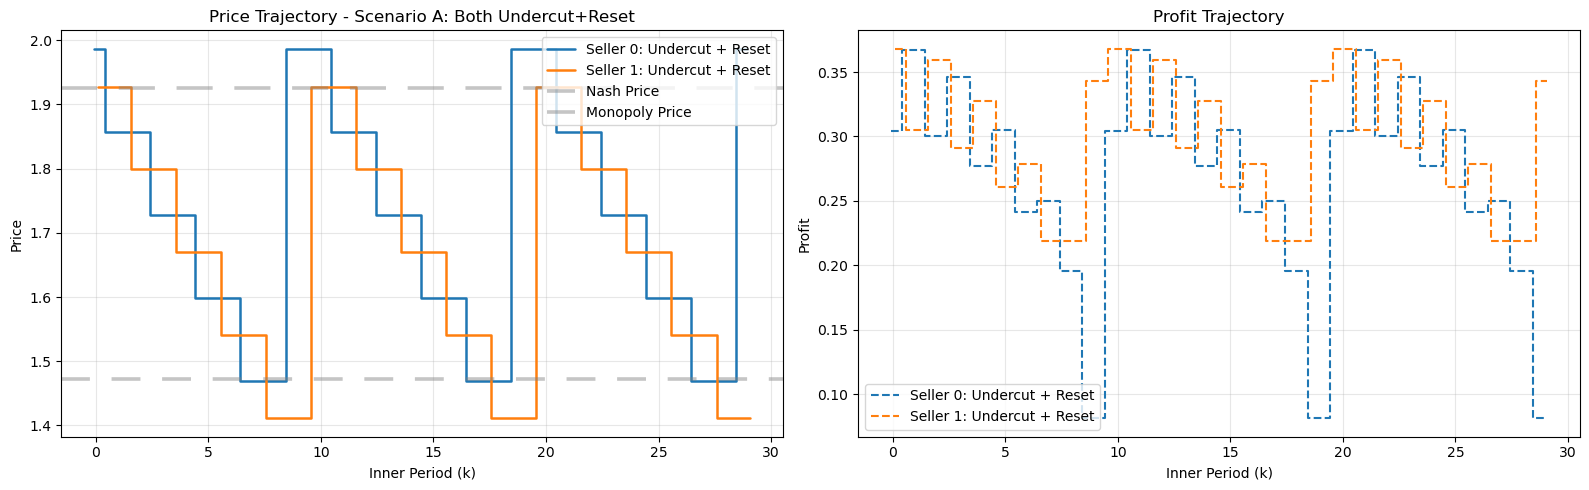

In [5]:
# Cell 4: 实验场景 A - 经典 Edgeworth Cycle 机制
# 设定: N=2, 两个人都用 "Undercut with Reset"
# 预期: 价格轮流下降，到底部后一人重置，另一人跟随重置

n = 2
strategies = [ACT_UNDER_RESET, ACT_MATCH_RESET, ACT_ABOVE]
actions = [ACT_UNDER_RESET, ACT_UNDER_RESET] # 两人都 Undercut+Reset

# 初始价格: 一个高一个低
start_p = [9, 8] # Grid Index (最高价, 次高价)

df_micro, grid, p_nash, p_mon = simulate_inner_dynamics(
    n_sellers=n, 
    active_strategies=strategies, 
    fixed_actions=actions, 
    start_prices=start_p, 
    K=30,  # 只需要看前30步
    mu=0.25
)

plot_micro_dynamics(
    df_micro,
    "Scenario A: Both Undercut+Reset",
    strategy_names=[ACTION_NAME[aid] for aid in actions],
    p_nash=p_nash,
    p_mon=p_mon,
    save_path=OUTPUT_DIR / "scenario_a_2p_undercut_reset.png",
)

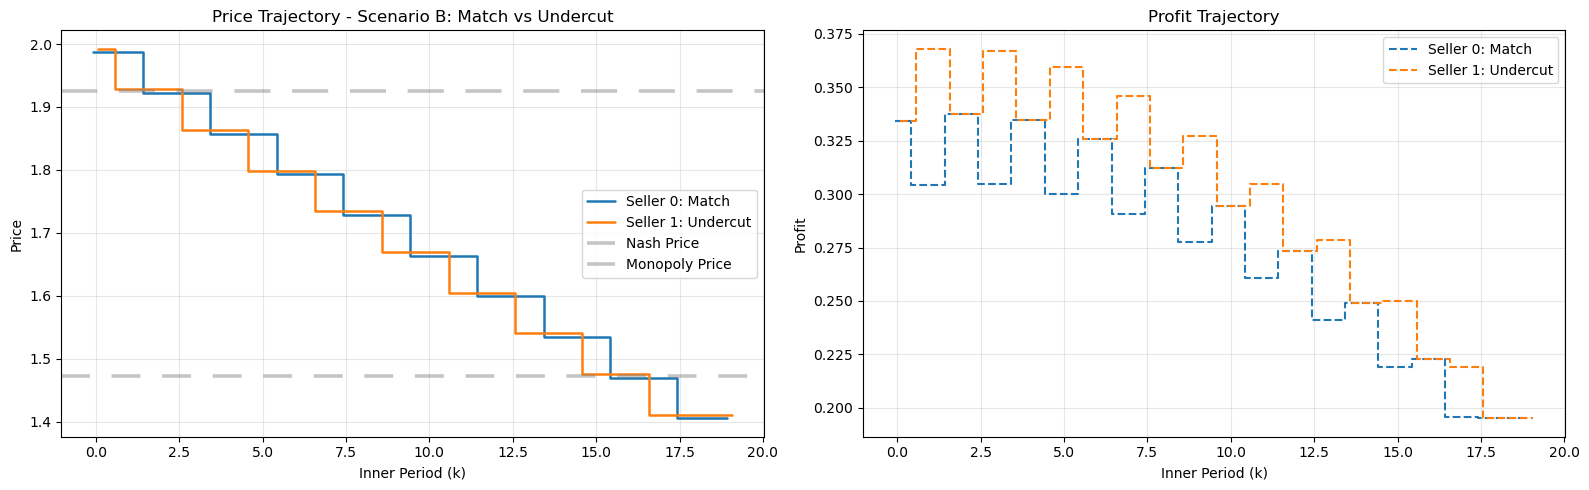

In [6]:
# Cell 5: 实验场景 B - 不对称策略
# 设定: N=2, Seller 0 用 "Match", Seller 1 用 "Undercut"
# 预期: Seller 1 拉低价格，Seller 0 跟随，直到降无可降 (Price War to Nash)

actions_b = [ACT_MATCH, ACT_UNDERCUT]

df_micro_b, _, p_nash_b, p_mon_b = simulate_inner_dynamics(
    n_sellers=2, 
    active_strategies=[ACT_UNDERCUT, ACT_MATCH], 
    fixed_actions=actions_b, 
    start_prices=[9, 9], 
    K=20,
    mu=0.25
)

plot_micro_dynamics(
    df_micro_b,
    "Scenario B: Match vs Undercut",
    strategy_names=[ACTION_NAME[aid] for aid in actions_b],
    p_nash=p_nash_b,
    p_mon=p_mon_b,
    save_path=OUTPUT_DIR / "scenario_b_2p_match_undercut.png",
)

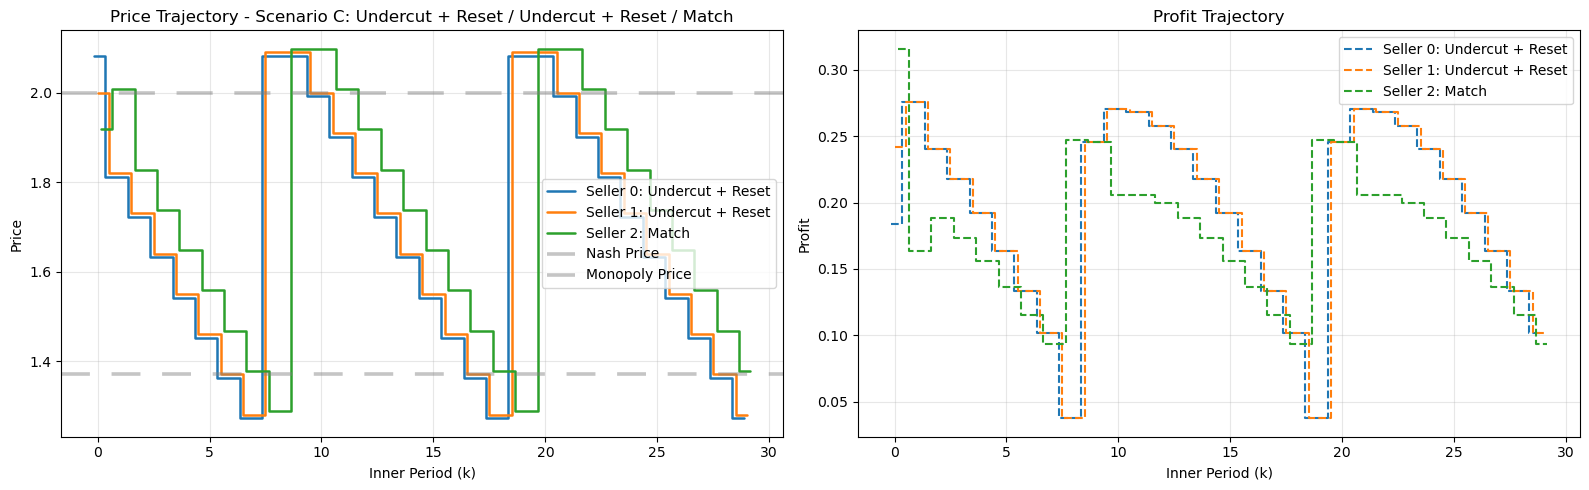

In [7]:
# Cell 6: 实验场景 C - N=3 的混乱
# 设定: N=3, Undercut+Reset / Undercut+Reset / Match

actions_c = [ACT_UNDER_RESET, ACT_UNDER_RESET, ACT_MATCH]

df_micro_c, _, p_nash_c, p_mon_c = simulate_inner_dynamics(
    n_sellers=3, 
    active_strategies=strategies, 
    fixed_actions=actions_c, 
    start_prices=[9, 8, 7], 
    K=30,
    mu=0.25
)

plot_micro_dynamics(
    df_micro_c,
    "Scenario C: Undercut + Reset / Undercut + Reset / Match",
    strategy_names=[ACTION_NAME[aid] for aid in actions_c],
    p_nash=p_nash_c,
    p_mon=p_mon_c,
    save_path=OUTPUT_DIR / "scenario_c_3p_undercut_reset_match.png",
)

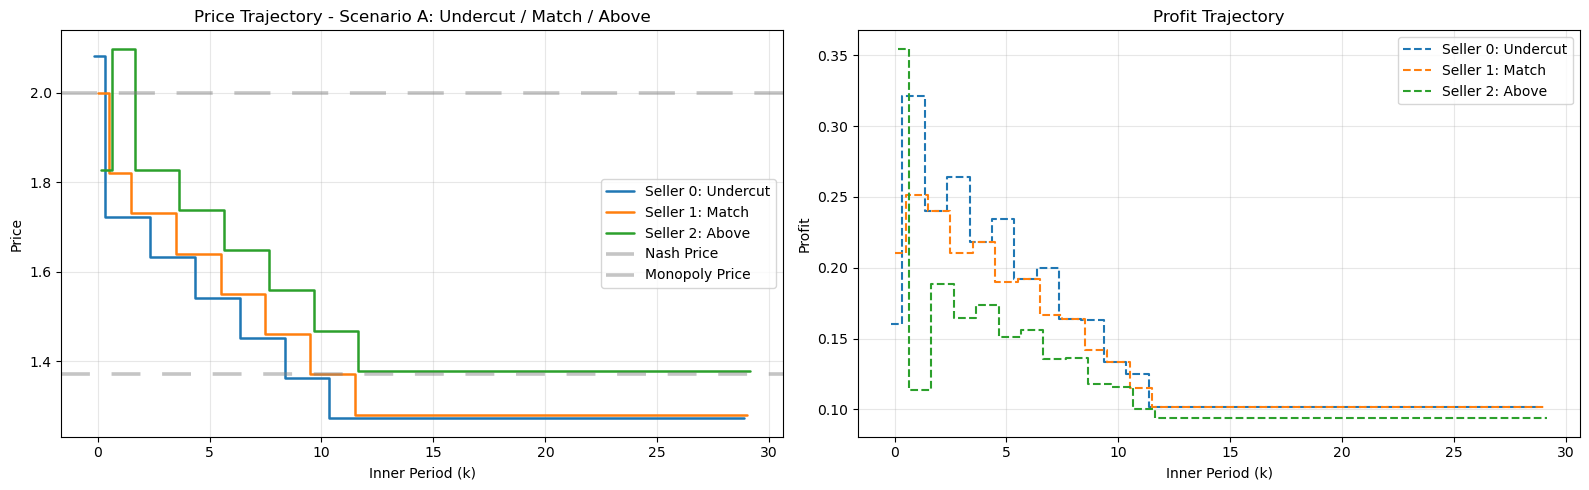

In [8]:
# Cell 7: 实验场景 A - N=3 Mixed
# 设定: N=3, Undercut / Match / Above

actions_c = [ACT_UNDERCUT, ACT_MATCH, ACT_ABOVE]

df_micro_c, _, p_nash_c, p_mon_c = simulate_inner_dynamics(
    n_sellers=3, 
    active_strategies=strategies, 
    fixed_actions=actions_c, 
    start_prices=[9, 8, 6], 
    K=30,
    mu=0.25
)

plot_micro_dynamics(
    df_micro_c,
    "Scenario A: Undercut / Match / Above",
    strategy_names=[ACTION_NAME[aid] for aid in actions_c],
    p_nash=p_nash_c,
    p_mon=p_mon_c,
    save_path=OUTPUT_DIR / "scenario_a_3p_undercut_match_above.png",
)

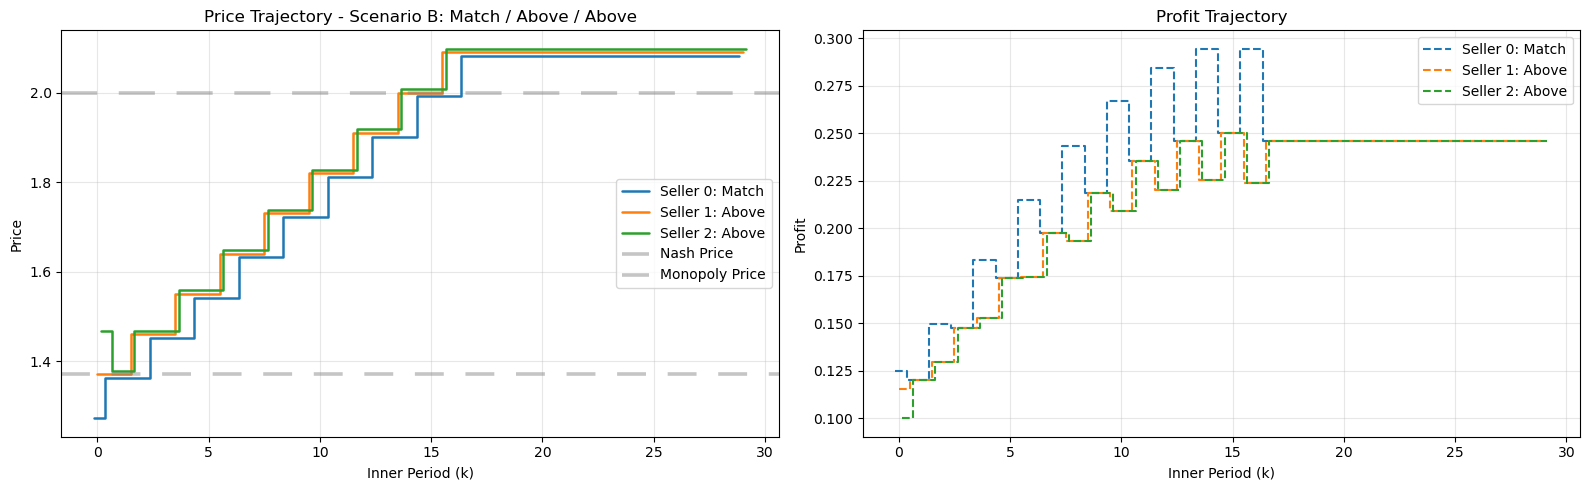

In [9]:
# Cell 8: 实验场景 B - N=3 Mixed
# 设定: N=3, Match / Above / Above

actions_c = [ACT_MATCH, ACT_ABOVE, ACT_ABOVE]

df_micro_c, _, p_nash_c, p_mon_c = simulate_inner_dynamics(
    n_sellers=3, 
    active_strategies=strategies, 
    fixed_actions=actions_c, 
    start_prices=[0, 1, 2], 
    K=30,
    mu=0.25
)

plot_micro_dynamics(
    df_micro_c,
    "Scenario B: Match / Above / Above",
    strategy_names=[ACTION_NAME[aid] for aid in actions_c],
    p_nash=p_nash_c,
    p_mon=p_mon_c,
    save_path=OUTPUT_DIR / "scenario_b_3p_match_above.png",
)